<a href="https://colab.research.google.com/github/hafisc/pcvk_2026/blob/main/Pertemuan%20Ke%205/praktikum5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Mohammad Al Hafis Hidayatulloh'
NIM  = '254107023005'
N    = int(NIM[-3:])

# Parameter dihitung dari NIM: N = 5
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),        # 2^((5%4)+3) = 2^4 = 16
    'clip' : round(1.0 + (N % 5)*0.5, 1), # 1.0 + 0*0.5 = 1.0
    'tile' : (N % 4) + 2,                # 1 + 2 = 3
    'L'    : 2 ** ((N % 3) + 1),         # 2^(2+1) = 8
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA  :', NAMA)
print('NIM   :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])


NAMA  : Mohammad Al Hafis Hidayatulloh
NIM   : 254107023005 | N = 5
bins   : 16
clip   : 1.0
tile   : 3
L      : 8
WAKTU : 2026-09-29 01:29:31 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 87b8477d37971fdf


In [87]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

# Path folder gambar - tetapkan sekali, pakai di seluruh percobaan
CONTOH = '/content/drive/MyDrive/pcvk_2026'   # citra contoh bersama
BASE   = '/content/drive/MyDrive/pcvk_2026'   # citra KTM milik saya


## E-1 Percobaan Histogram

### Percobaan Utama: Membuat Histogram Citra
Tahap 1 dengan lena.jpg, Tahap 2 dengan ktm_ruang.jpeg.


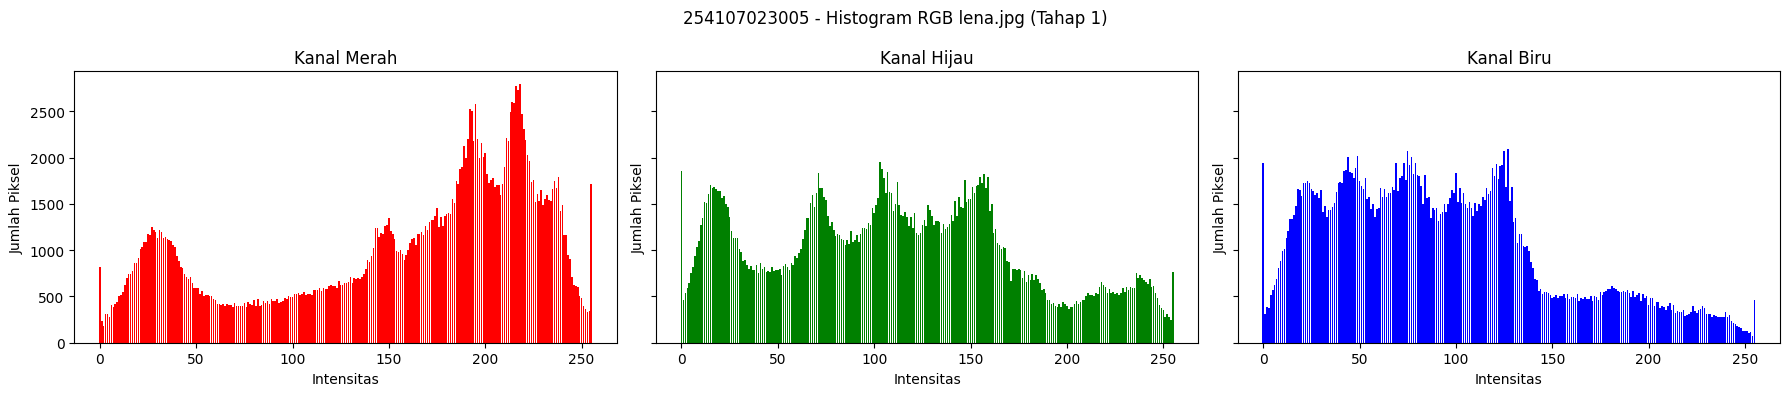

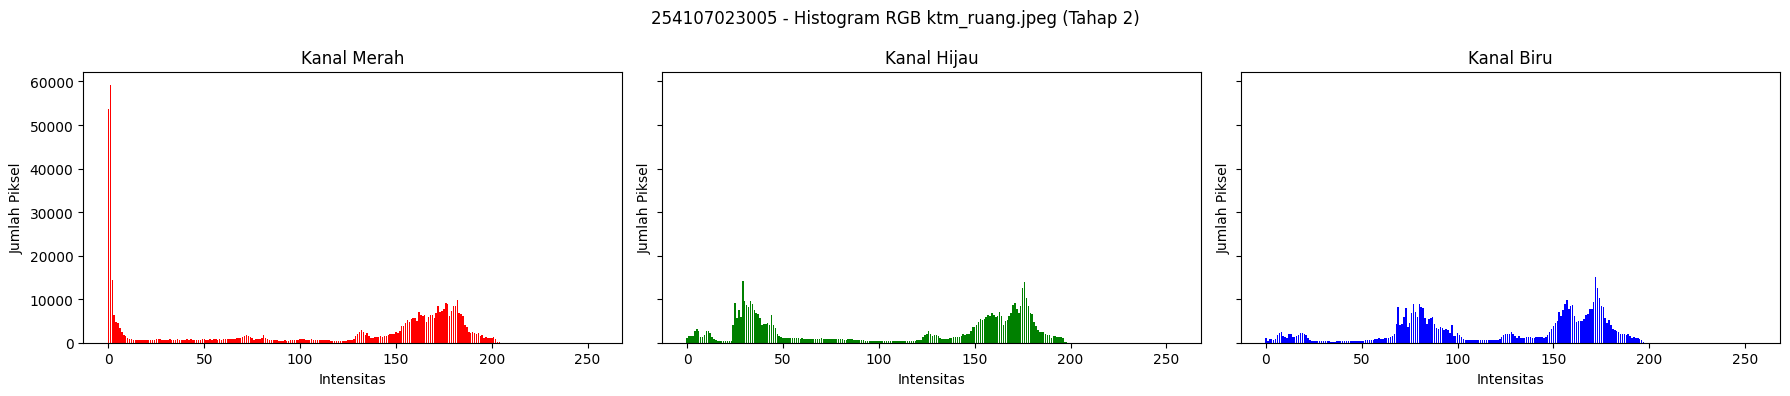

In [89]:
# --- TAHAP 1: Histogram RGB lena.jpg (manual, piksel demi piksel) ---
bgr_lena = cv.imread(CONTOH + '/lena.jpg')
img_rgb  = cv.cvtColor(bgr_lena, cv.COLOR_BGR2RGB)
tinggi, lebar, _ = img_rgb.shape

red = [0]*256; green = [0]*256; blue = [0]*256
for y in range(tinggi):
    for x in range(lebar):
        red[img_rgb[y, x, 0]]   += 1
        green[img_rgb[y, x, 1]] += 1
        blue[img_rgb[y, x, 2]]  += 1

sumbu = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB lena.jpg (Tahap 1)')
axs[0].bar(sumbu, red,   color='red');   axs[0].set_title('Kanal Merah')
axs[1].bar(sumbu, green, color='green'); axs[1].set_title('Kanal Hijau')
axs[2].bar(sumbu, blue,  color='blue');  axs[2].set_title('Kanal Biru')
for ax in axs:
    ax.set_xlabel('Intensitas'); ax.set_ylabel('Jumlah Piksel')
plt.tight_layout()
plt.show()

# --- TAHAP 2: Histogram RGB ktm_ruang.jpeg ---
bgr_ktm1b_col = cv.imread(BASE + '/ktm_ruang.jpeg')
if bgr_ktm1b_col is not None:
    rgb_ktm = cv.cvtColor(bgr_ktm1b_col, cv.COLOR_BGR2RGB)
    h2, w2, _ = rgb_ktm.shape
    r2 = [0]*256; g2 = [0]*256; b2 = [0]*256
    for y in range(h2):
        for x in range(w2):
            r2[rgb_ktm[y, x, 0]] += 1
            g2[rgb_ktm[y, x, 1]] += 1
            b2[rgb_ktm[y, x, 2]] += 1
    fig2, ax2 = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)
    fig2.suptitle(NIM + ' - Histogram RGB ktm_ruang.jpeg (Tahap 2)')
    ax2[0].bar(sumbu, r2, color='red');   ax2[0].set_title('Kanal Merah')
    ax2[1].bar(sumbu, g2, color='green'); ax2[1].set_title('Kanal Hijau')
    ax2[2].bar(sumbu, b2, color='blue');  ax2[2].set_title('Kanal Biru')
    for ax in ax2:
        ax.set_xlabel('Intensitas'); ax.set_ylabel('Jumlah Piksel')
    plt.tight_layout()
    plt.show()


### Pertanyaan E-1 No.1
Bandingkan histogram manual, numpy.histogram, dan cv.calcHist. Selisih harus nol.


In [90]:
def histogram_manual(img_gray, L=256):
    """Menghitung histogram secara manual dengan perulangan piksel."""
    h = np.zeros(L, dtype=np.int64)
    for y in range(img_gray.shape[0]):
        for x in range(img_gray.shape[1]):
            h[img_gray[y, x]] += 1
    return h

def cek_selisih(path, judul):
    gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if gray is None:
        print('[!] File tidak ditemukan:', path); return

    h_manual = histogram_manual(gray)
    h_np, _  = np.histogram(gray.flatten(), bins=256, range=(0, 256))
    h_cv     = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

    print('===', judul, '===')
    print('Selisih manual vs numpy.histogram :', np.max(np.abs(h_manual - h_np)))
    print('Selisih manual vs cv.calcHist     :', np.max(np.abs(h_manual - h_cv)))
    print('Selisih numpy  vs cv.calcHist     :', np.max(np.abs(h_np    - h_cv)))
    print()

# Tahap 1: lena.jpg
cek_selisih(CONTOH + '/lena.jpg', 'lena.jpg (Tahap 1)')
# Tahap 2: ktm_ruang.jpeg
cek_selisih(BASE + '/ktm_ruang.jpeg', NIM + ' - ktm_ruang.jpeg (Tahap 2)')


=== lena.jpg (Tahap 1) ===
Selisih manual vs numpy.histogram : 0
Selisih manual vs cv.calcHist     : 0
Selisih numpy  vs cv.calcHist     : 0

=== 254107023005 - ktm_ruang.jpeg (Tahap 2) ===
Selisih manual vs numpy.histogram : 0
Selisih manual vs cv.calcHist     : 0
Selisih numpy  vs cv.calcHist     : 0



**Jawaban Pertanyaan E-1 No.1:**

Ketiga metode menghasilkan nilai yang identik—selisih maksimumnya nol. Ini masuk akal karena ketiganya mengerjakan hal yang persis sama: menghitung frekuensi kemunculan setiap nilai intensitas dari 0 sampai 255. Perbedaannya hanya dari sisi kecepatan eksekusi. Perulangan manual Python paling lambat karena interpreter memproses tiap piksel satu per satu. `numpy.histogram` dan `cv.calcHist` jauh lebih cepat karena komputasinya dikerjakan di level C yang sudah dioptimasi.


### Pertanyaan E-1 No.2
Histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a–KTM1d dalam satu figure 2x2.


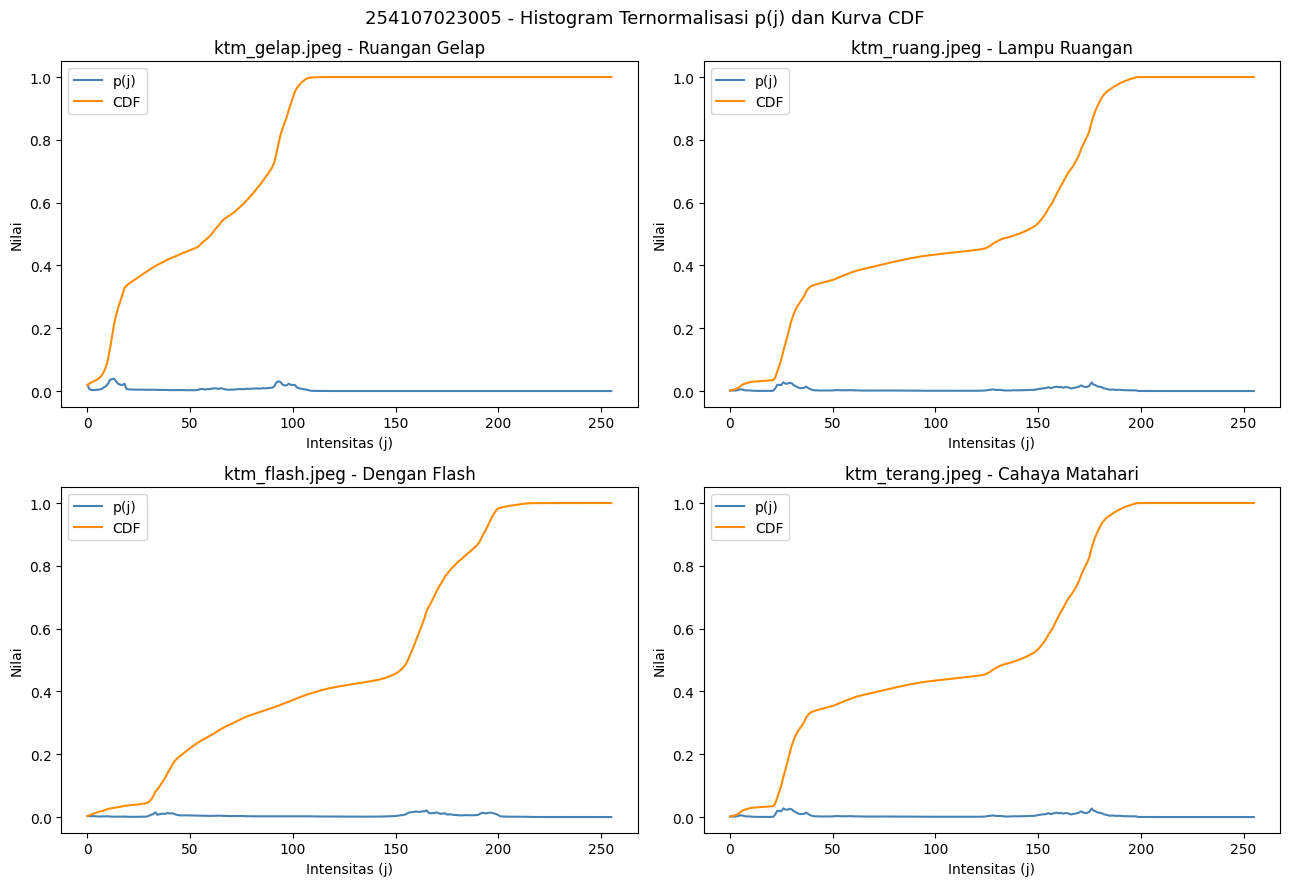

Rerata kecerahan (0=hitam, 255=putih):
  ktm_gelap.jpeg : 54.79
  ktm_ruang.jpeg : 108.36
  ktm_flash.jpeg : 123.91
  ktm_terang.jpeg : 108.36


In [91]:
daftar_ktm   = ['ktm_gelap.jpeg', 'ktm_ruang.jpeg', 'ktm_flash.jpeg', 'ktm_terang.jpeg']
kondisi_cahaya = ['Ruangan Gelap', 'Lampu Ruangan', 'Dengan Flash', 'Cahaya Matahari']

fig, axs = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(NIM + ' - Histogram Ternormalisasi p(j) dan Kurva CDF', fontsize=13)
axs = axs.flatten()

rerata = {}
for i, (nama, ket) in enumerate(zip(daftar_ktm, kondisi_cahaya)):
    gray = cv.imread(BASE + '/' + nama, cv.IMREAD_GRAYSCALE)
    axs[i].set_title(nama + ' - ' + ket)
    if gray is None:
        axs[i].text(0.5, 0.5, nama + ' belum diupload', ha='center', transform=axs[i].transAxes)
        axs[i].axis('off'); continue
    h   = histogram_manual(gray)
    pj  = h / gray.size
    cdf = np.cumsum(pj)
    rerata[nama] = gray.mean()
    axs[i].plot(pj,  color='steelblue',  label='p(j)')
    axs[i].plot(cdf, color='darkorange', label='CDF')
    axs[i].set_xlabel('Intensitas (j)'); axs[i].set_ylabel('Nilai')
    axs[i].legend()

plt.tight_layout()
plt.show()

print('Rerata kecerahan (0=hitam, 255=putih):')
for k, v in rerata.items():
    print('  %-12s : %.2f' % (k, v))


**Jawaban Pertanyaan E-1 No.2:**

- **Citra paling gelap (KTM1a - Ruangan Gelap)**: Piksel menumpuk di nilai intensitas kecil, sehingga kurva p(j) menumpuk di sisi kiri. Kurva CDF naik sangat curam di awal dan cepat mendekati 1 sebelum pertengahan sumbu-x. Ini mengindikasikan pencahayaan sangat minim saat akuisisi di Pertemuan 2.
- **Citra paling terang (KTM1d - Cahaya Matahari)**: Piksel menumpuk di nilai tinggi (dekat 255). Kurva p(j) menumpuk di sisi kanan, sedangkan CDF-nya tetap hampir nol di awal dan baru naik tajam mendekati nilai 255. Ini mencerminkan paparan sinar matahari langsung.
- **Kesimpulan**: Bentuk CDF mencerminkan kondisi pencahayaan. CDF yang naik curam di kiri → citra gelap; naik curam di kanan → citra terang; naik landai dan merata → distribusi pencahayaan seimbang (misal lampu ruangan).


### Pertanyaan E-1 No.3
Histogram ktm_ruang.jpeg dengan PARAM['bins'] (=16) vs 256 bin.


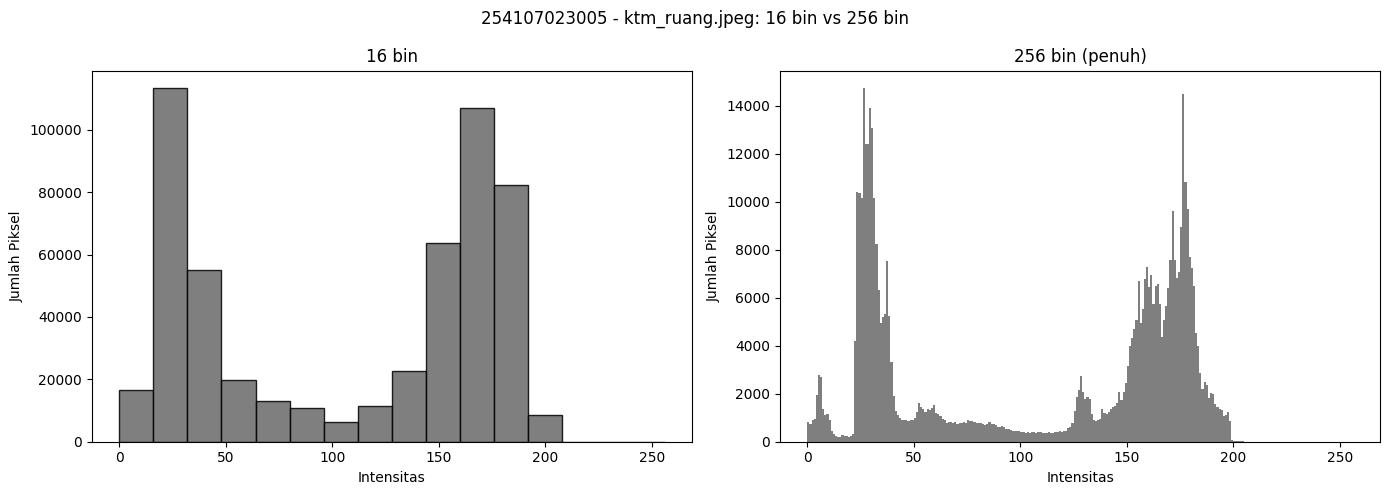

In [92]:
gray_ktm1b = cv.imread(BASE + '/ktm_ruang.jpeg', cv.IMREAD_GRAYSCALE)

if gray_ktm1b is not None:
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(NIM + ' - ktm_ruang.jpeg: ' + str(PARAM['bins']) + ' bin vs 256 bin')

    axs[0].hist(gray_ktm1b.flatten(), bins=PARAM['bins'], range=(0,256), color='dimgray', edgecolor='black', alpha=0.85)
    axs[0].set_title(str(PARAM['bins']) + ' bin')
    axs[0].set_xlabel('Intensitas'); axs[0].set_ylabel('Jumlah Piksel')

    axs[1].hist(gray_ktm1b.flatten(), bins=256, range=(0,256), color='dimgray', alpha=0.85)
    axs[1].set_title('256 bin (penuh)')
    axs[1].set_xlabel('Intensitas'); axs[1].set_ylabel('Jumlah Piksel')

    plt.tight_layout()
    plt.show()


**Jawaban Pertanyaan E-1 No.3:**

Dengan `bins=16`, setiap batang mewakili gabungan 16 nilai intensitas (256/16 = 16 nilai per bin). Beberapa informasi yang hilang:
1. **Puncak-puncak tajam** pada nilai intensitas tertentu tidak bisa dibedakan karena digabung ke satu kelompok.
2. **Celah/lembah** antar nilai yang berdekatan menjadi tidak terlihat, seolah terhapus.
3. **Distribusi lokal sempit** (misalnya teks pada KTM yang nilainya berbeda beberapa unit saja) melebur ke dalam satu batang.

Semakin sedikit bin, resolusi histogram semakin kasar. Gambaran umum distribusi masih terlihat, tetapi detail-detail halus hilang.


## E-2 Percobaan Histogram Equalization

### Langkah 1: Histogram Equalization Manual
Tahap 1 dengan lena_lc.jpg (verifikasi), Tahap 2 dengan ktm_gelap.jpeg (analisis).


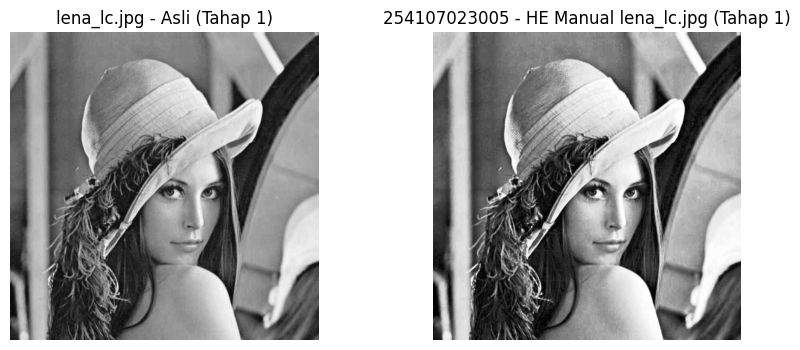

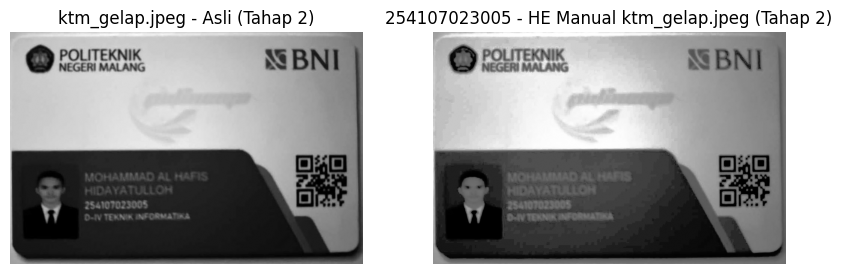

In [93]:
def he_manual(gray, L=256):
    """HE manual: hitung CDF lalu mapping K0 = round(CDF * (L-1))."""
    h   = histogram_manual(gray, L)
    p   = h / gray.size
    cdf = np.cumsum(p)
    K0  = np.round(cdf * (L - 1)).astype(np.uint8)
    return K0[gray]

# ---------- TAHAP 1: lena_lc.jpg ----------
gray_lena_lc = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
if gray_lena_lc is not None:
    hasil_lc = he_manual(gray_lena_lc)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(gray_lena_lc, cmap='gray')
    plt.title('lena_lc.jpg - Asli (Tahap 1)'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(hasil_lc, cmap='gray')
    plt.title(NIM + ' - HE Manual lena_lc.jpg (Tahap 1)'); plt.axis('off')
    plt.show()

# ---------- TAHAP 2: ktm_gelap.jpeg ----------
gray_ktm1a = cv.imread(BASE + '/ktm_gelap.jpeg', cv.IMREAD_GRAYSCALE)
if gray_ktm1a is not None:
    hasil_ktm1a = he_manual(gray_ktm1a)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(gray_ktm1a, cmap='gray')
    plt.title('ktm_gelap.jpeg - Asli (Tahap 2)'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(hasil_ktm1a, cmap='gray')
    plt.title(NIM + ' - HE Manual ktm_gelap.jpeg (Tahap 2)'); plt.axis('off')
    plt.show()


### Langkah 2: Bandingkan HE Manual dengan cv.equalizeHist


In [94]:
def bandingkan_he(path, judul):
    gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if gray is None: print('[!] Tidak ditemukan:', path); return
    h_manual = he_manual(gray)
    h_cv2    = cv.equalizeHist(gray)
    selisih  = np.max(np.abs(h_manual.astype(int) - h_cv2.astype(int)))
    print('===', judul, '===')
    print('Selisih maksimum HE manual vs cv.equalizeHist:', selisih)
    print()

# Tahap 1
bandingkan_he(CONTOH + '/lena_lc.jpg', 'lena_lc.jpg (Tahap 1)')
# Tahap 2
bandingkan_he(BASE + '/ktm_gelap.jpeg', NIM + ' - ktm_gelap.jpeg (Tahap 2)')


=== lena_lc.jpg (Tahap 1) ===
Selisih maksimum HE manual vs cv.equalizeHist: 0

=== 254107023005 - ktm_gelap.jpeg (Tahap 2) ===
Selisih maksimum HE manual vs cv.equalizeHist: 5



### Langkah 3: Ekualisasi Citra Berwarna (Kanal B, G, R)


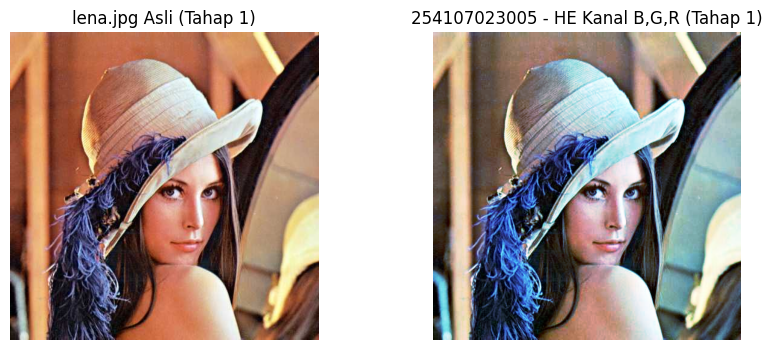

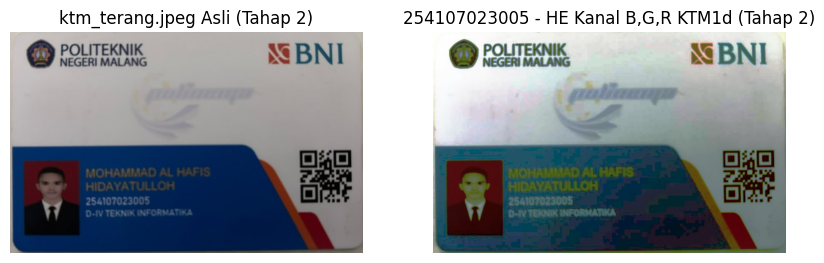

In [95]:
# --- TAHAP 1: lena.jpg ---
bgr_l = cv.imread(CONTOH + '/lena.jpg')
if bgr_l is not None:
    kanal_l = list(cv.split(bgr_l))
    for i in range(3): kanal_l[i] = cv.equalizeHist(kanal_l[i])
    he_bgr_l = cv.merge(kanal_l)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(bgr_l,    cv.COLOR_BGR2RGB))
    plt.title('lena.jpg Asli (Tahap 1)'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(he_bgr_l, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - HE Kanal B,G,R (Tahap 1)'); plt.axis('off')
    plt.show()

# --- TAHAP 2: ktm_terang.jpeg ---
bgr_d = cv.imread(BASE + '/ktm_terang.jpeg')
if bgr_d is not None:
    kanal_d = list(cv.split(bgr_d))
    for i in range(3): kanal_d[i] = cv.equalizeHist(kanal_d[i])
    he_bgr_d = cv.merge(kanal_d)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(bgr_d,    cv.COLOR_BGR2RGB))
    plt.title('ktm_terang.jpeg Asli (Tahap 2)'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(he_bgr_d, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - HE Kanal B,G,R KTM1d (Tahap 2)'); plt.axis('off')
    plt.show()


### Langkah 4: Ekualisasi Hanya Kanal Kecerahan (Y / V / L)


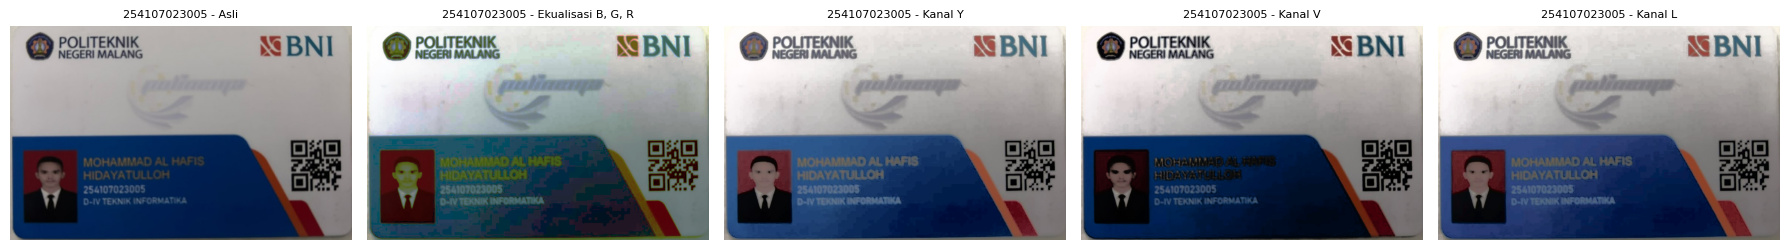

Cara                   Geser Hue (derajat)   Rerata Terang
----------------------------------------------------------
Asli                                 0.00           108.4
Ekualisasi B, G, R                  76.10           125.2
Kanal Y                              0.35           128.9
Kanal V                              2.11           113.3
Kanal L                              5.93           123.2


In [96]:
bgr = cv.imread(BASE + '/ktm_terang.jpeg')
if bgr is None:
    bgr = cv.imread(CONTOH + '/lena.jpg')

if bgr is not None:
    # HE kanal B,G,R terpisah (cara 1)
    ks = list(cv.split(bgr))
    for i in range(3): ks[i] = cv.equalizeHist(ks[i])
    he_rgb = cv.merge(ks)

    # Hanya kanal Y (YCrCb)
    ycrcb      = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb  = cv.split(ycrcb)
    he_y       = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # Hanya kanal V (HSV)
    hsv        = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    hh, s, v   = cv.split(hsv)
    he_v       = cv.cvtColor(cv.merge([hh, s, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # Hanya kanal L (LAB)
    lab        = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b    = cv.split(lab)
    he_l       = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    judul_list = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra_list = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra_list, judul_list), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Ukur pergeseran Hue
    def geser_hue(asli, hasil):
        h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:,:,0].astype(np.int16)
        h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:,:,0].astype(np.int16)
        d  = np.abs(h1 - h2)
        d  = np.minimum(d, 180 - d)
        return d.mean()

    print('%-22s %18s %15s' % ('Cara', 'Geser Hue (derajat)', 'Rerata Terang'))
    print('-' * 58)
    for t, c in zip(judul_list, citra_list):
        gh = geser_hue(bgr, c) * 2
        tr = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        print('%-22s %18.2f %15.1f' % (t, gh, tr))


**Jawaban Pertanyaan Kanal Terang (Langkah 4):**

1. Metode yang menghasilkan pergeseran Hue paling besar adalah **Ekualisasi B, G, R secara terpisah** karena masing-masing kanal warna dimanipulasi sendiri-sendiri tanpa memperhitungkan keseimbangan antar kanal, sehingga perpaduan warna aslinya berubah secara signifikan.
2. Ekualisasi kanal terang (Y/V/L) tetap menghasilkan pergeseran Hue yang tidak persis nol karena proses konversi ruang warna (BGR ↔ YCrCb / HSV / LAB) melibatkan **pembulatan dan pemotongan nilai integer**. Meski secara teori hanya kanal kecerahan yang disentuh, kebocoran numerik akibat pembulatan saat konversi bolak-balik menyebabkan nilai piksel sedikit bergeser di semua kanal.
3. Di antara Y, V, dan L, **kanal L (LAB)** paling sesuai untuk foto KTM karena ruang warna LAB dirancang sesuai persepsi manusia. Peningkatan kontras terasa natural dan pergeseran warna asli paling minimal.


Kanal L + equalizeHist : Geser Hue = 5.93 | Rerata Terang = 123.2
Kanal L + CLAHE        : Geser Hue = 4.89 | Rerata Terang = 117.1
(PARAM clip=1.0, tile=3x3  dari NIM 254107023005)


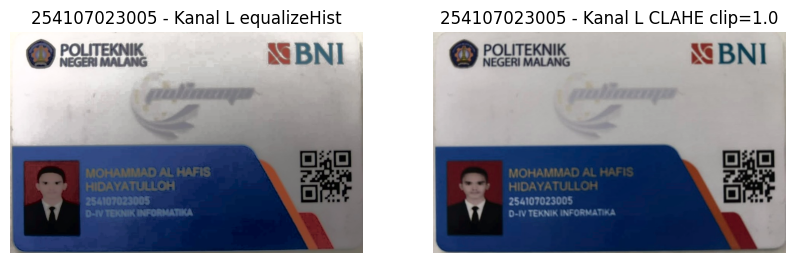

In [97]:
# Soal 4: Ganti equalizeHist dengan CLAHE pada kanal L
if bgr is not None:
    clahe_obj  = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
    lab2       = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l2, a2, b2 = cv.split(lab2)
    he_l_clahe = cv.cvtColor(cv.merge([clahe_obj.apply(l2), a2, b2]), cv.COLOR_LAB2BGR)

    g_biasa = geser_hue(bgr, he_l)       * 2
    g_clahe = geser_hue(bgr, he_l_clahe) * 2
    t_biasa = cv.cvtColor(he_l,       cv.COLOR_BGR2GRAY).mean()
    t_clahe = cv.cvtColor(he_l_clahe, cv.COLOR_BGR2GRAY).mean()

    print('Kanal L + equalizeHist : Geser Hue = %.2f | Rerata Terang = %.1f' % (g_biasa, t_biasa))
    print('Kanal L + CLAHE        : Geser Hue = %.2f | Rerata Terang = %.1f' % (g_clahe, t_clahe))
    print('(PARAM clip=%.1f, tile=%dx%d  dari NIM %s)' % (PARAM['clip'], PARAM['tile'], PARAM['tile'], NIM))

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(he_l,       cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - Kanal L equalizeHist'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(he_l_clahe, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - Kanal L CLAHE clip=' + str(PARAM['clip'])); plt.axis('off')
    plt.show()


### Pertanyaan Praktikum E-2

**Soal 1**: Ekualisasi global pada ktm_gelap.jpeg (grayscale) + tampilan histogram + PSNR


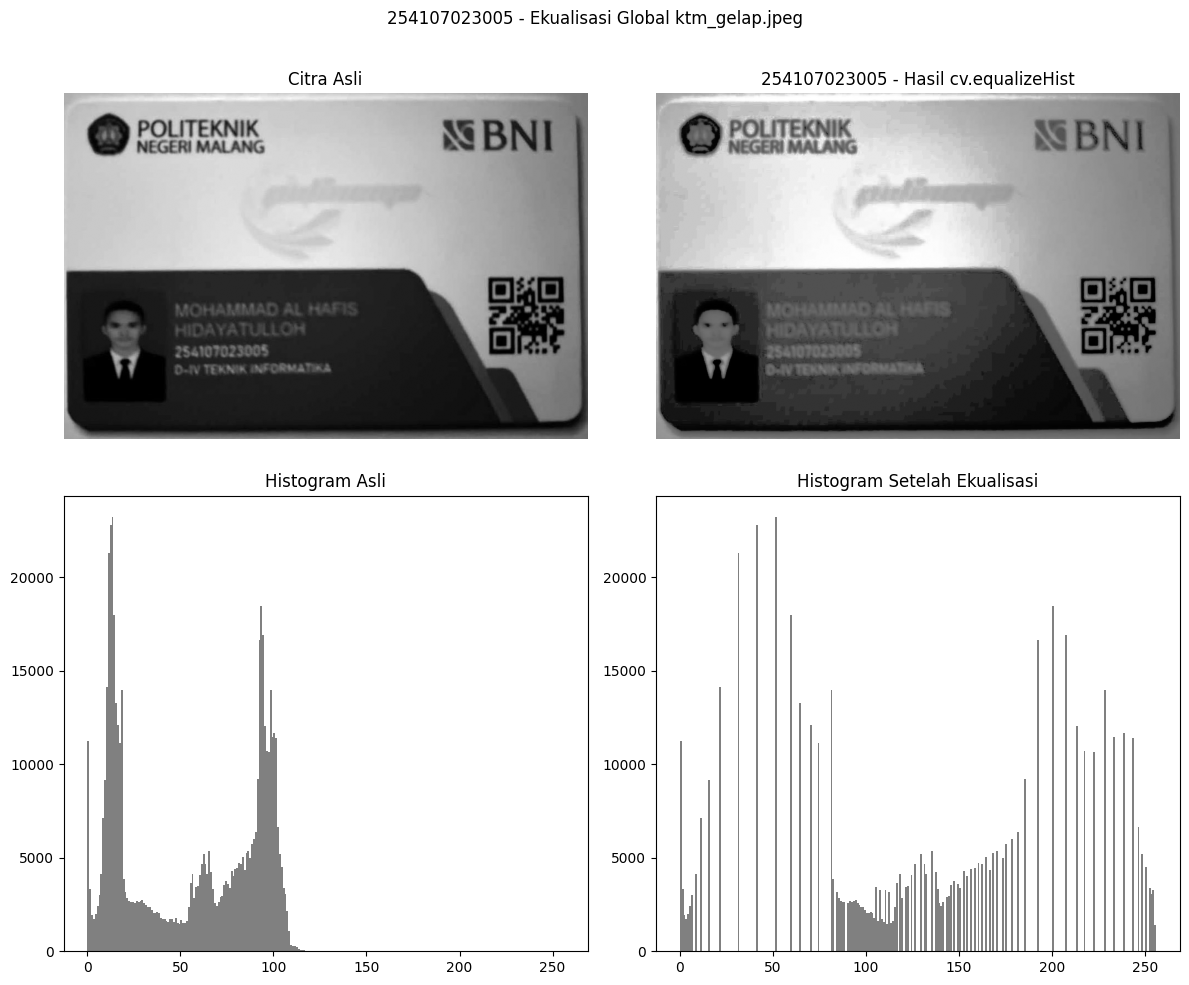

MSE  : 6844.304601695627
PSNR : 9.777510315517594 dB


In [98]:
if gray_ktm1a is not None:
    he_ktm1a_cv = cv.equalizeHist(gray_ktm1a)

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(NIM + ' - Ekualisasi Global ktm_gelap.jpeg')

    axs[0,0].imshow(gray_ktm1a,   cmap='gray')
    axs[0,0].set_title('Citra Asli'); axs[0,0].axis('off')

    axs[0,1].imshow(he_ktm1a_cv,  cmap='gray')
    axs[0,1].set_title(NIM + ' - Hasil cv.equalizeHist'); axs[0,1].axis('off')

    axs[1,0].hist(gray_ktm1a.flatten(),  bins=256, range=(0,256), color='gray')
    axs[1,0].set_title('Histogram Asli')

    axs[1,1].hist(he_ktm1a_cv.flatten(), bins=256, range=(0,256), color='gray')
    axs[1,1].set_title('Histogram Setelah Ekualisasi')

    plt.tight_layout()
    plt.show()

    # Hitung MSE dan PSNR
    mse  = np.mean((gray_ktm1a.astype(np.float64) - he_ktm1a_cv.astype(np.float64)) ** 2)
    psnr = 10 * math.log10((255**2) / mse) if mse > 0 else float('inf')
    print('MSE  :', mse)
    print('PSNR :', psnr, 'dB')


**Jawaban Soal 1c – Mengapa PSNR turun padahal citra lebih jelas?**

PSNR mengukur kemiripan matematis antara dua citra berdasarkan selisih nilai piksel (MSE). HE dengan sengaja mengubah nilai piksel secara besar-besaran agar detail yang tersembunyi menjadi terlihat. Perubahan besar ini membuat MSE membengkak dan PSNR pun turun.

**Kesimpulan**: PSNR tidak cocok untuk menilai keterbacaan atau kualitas perseptual citra hasil enhancement. PSNR hanya mengukur kesamaan angka piksel dengan citra referensi. Untuk menilai keterbacaan foto KTM, evaluasi visual langsung lebih relevan dari pada nilai PSNR.


**Soal 2**: CLAHE pada ktm_gelap.jpeg


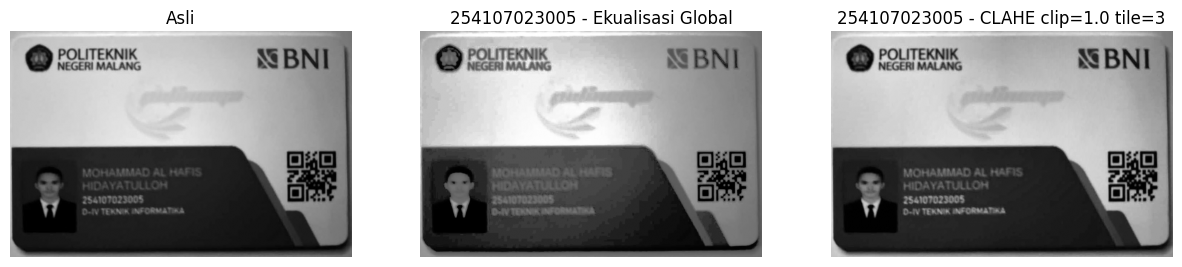

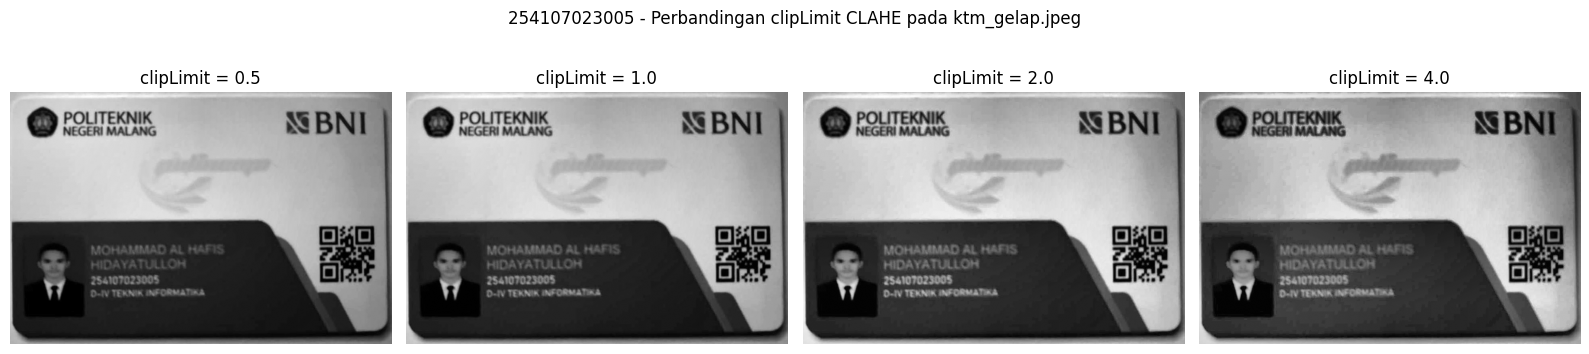

In [99]:
if gray_ktm1a is not None:
    clahe_e2       = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil_clahe_e2 = clahe_e2.apply(gray_ktm1a)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(gray_ktm1a,     cmap='gray')
    plt.title('Asli'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(he_ktm1a_cv,    cmap='gray')
    plt.title(NIM + ' - Ekualisasi Global'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(hasil_clahe_e2, cmap='gray')
    plt.title(NIM + ' - CLAHE clip=%.1f tile=%d' % (PARAM['clip'], PARAM['tile'])); plt.axis('off')
    plt.show()

    # Soal 2b: Coba tiga nilai clipLimit lain di sekitar PARAM['clip']
    clip_list = [0.5, PARAM['clip'], 2.0, 4.0]
    plt.figure(figsize=(16, 4))
    plt.suptitle(NIM + ' - Perbandingan clipLimit CLAHE pada ktm_gelap.jpeg')
    for i, cl in enumerate(clip_list):
        cl_obj = cv.createCLAHE(clipLimit=cl, tileGridSize=(PARAM['tile'], PARAM['tile']))
        hasil  = cl_obj.apply(gray_ktm1a)
        plt.subplot(1, len(clip_list), i+1)
        plt.imshow(hasil, cmap='gray')
        plt.title('clipLimit = ' + str(cl))
        plt.axis('off')
    plt.tight_layout()
    plt.show()


**Jawaban Soal 2a**: CLAHE lebih baik untuk menampilkan teks KTM karena bekerja secara lokal per-tile, bukan global. Area kecil berisi tulisan NIM/nama mendapat peningkatan kontras yang disesuaikan dengan karakteristik lokalnya, tidak terpengaruh area lain.

**Jawaban Soal 2b**: Semakin besar `clipLimit`, kontras per-tile semakin kuat. Pada nilai kecil (0.5) peningkatan nyaris tidak terasa. Nilai `PARAM['clip']=1.0` (dihitung dari NIM saya) memberikan keseimbangan yang cukup baik antara keterbacaan teks dan munculnya noise. Ketika clipLimit dinaikkan ke 2.0 atau 4.0, noise di area latar belakang yang harusnya polos mulai ikut terangkat dan tampak kasar (bercak-bercak).


## E-3 Tugas Praktikum Dithering

### Fungsi Floyd-Steinberg


In [100]:
def floyd_steinberg(gray, L=2):
    """Dithering Floyd-Steinberg. L = jumlah level kuantisasi."""
    img  = gray.astype(np.float32).copy()   # float agar error tidak overflow/wraparound
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step    # warna palet terdekat
            img[y, x] = baru
            err  = lama - baru
            if x + 1 < W:              img[y,   x+1] += err * 7 / 16
            if x > 0 and y + 1 < H:   img[y+1, x-1] += err * 3 / 16
            if y + 1 < H:              img[y+1, x  ] += err * 5 / 16
            if x + 1 < W and y+1 < H: img[y+1, x+1] += err * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)


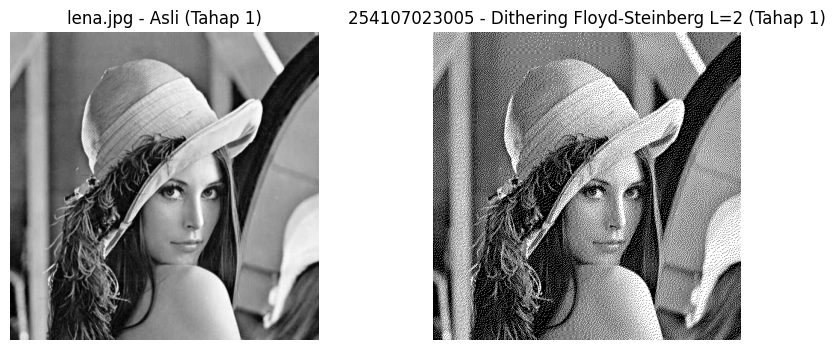

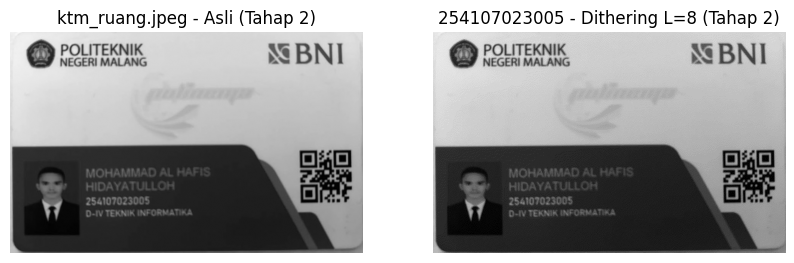

In [101]:
# ---- TAHAP 1: lena.jpg, L=2 ----
gray_lena = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)
if gray_lena is not None:
    dither_lena = floyd_steinberg(gray_lena, L=2)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(gray_lena,    cmap='gray')
    plt.title('lena.jpg - Asli (Tahap 1)'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(dither_lena,  cmap='gray')
    plt.title(NIM + ' - Dithering Floyd-Steinberg L=2 (Tahap 1)'); plt.axis('off')
    plt.show()

# ---- TAHAP 2: ktm_ruang.jpeg, L = PARAM['L'] = 8 ----
gray_ktm1b = cv.imread(BASE + '/ktm_ruang.jpeg', cv.IMREAD_GRAYSCALE)
if gray_ktm1b is not None:
    dither_ktm1b = floyd_steinberg(gray_ktm1b, L=PARAM['L'])
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(gray_ktm1b,    cmap='gray')
    plt.title('ktm_ruang.jpeg - Asli (Tahap 2)'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(dither_ktm1b,  cmap='gray')
    plt.title(NIM + ' - Dithering L=' + str(PARAM['L']) + ' (Tahap 2)'); plt.axis('off')
    plt.show()


### Soal 2: HE lalu Dithering vs Langsung Dithering


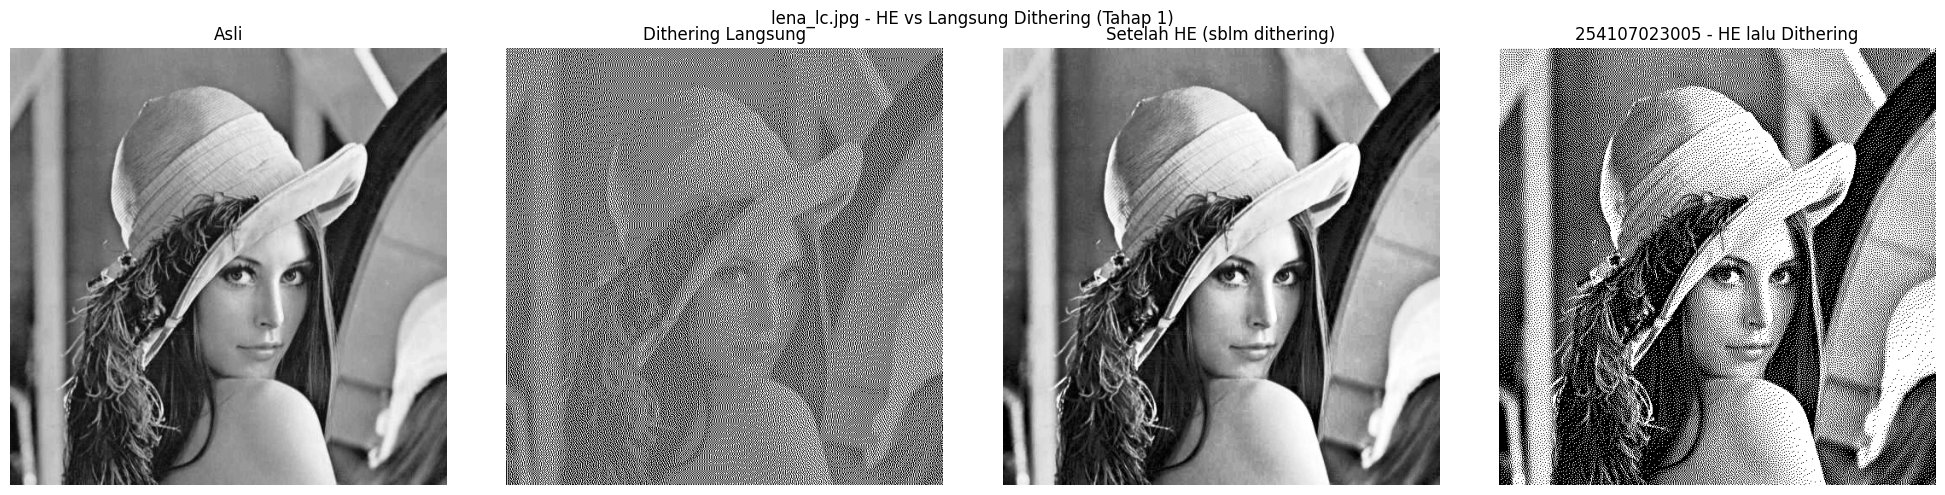

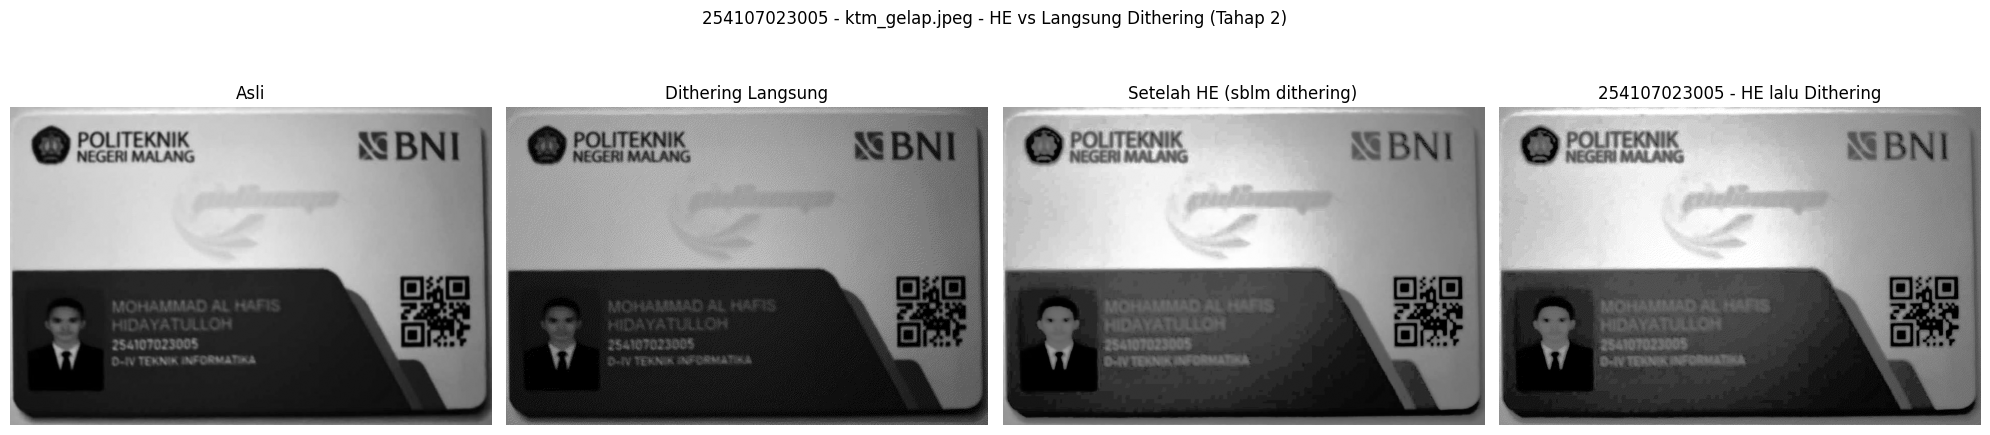

In [102]:
def alur_he_dithering(path_img, judul, L):
    gray = cv.imread(path_img, cv.IMREAD_GRAYSCALE)
    if gray is None: print('[!] Tidak ditemukan:', path_img); return

    # (a) dithering langsung tanpa ekualisasi
    dither_langsung = floyd_steinberg(gray, L=L)

    # (b) HE dulu, baru dithering
    gray_he   = cv.equalizeHist(gray)
    dither_he = floyd_steinberg(gray_he, L=L)

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(judul)
    axs[0].imshow(gray,             cmap='gray'); axs[0].set_title('Asli');                      axs[0].axis('off')
    axs[1].imshow(dither_langsung,  cmap='gray'); axs[1].set_title('Dithering Langsung');         axs[1].axis('off')
    axs[2].imshow(gray_he,          cmap='gray'); axs[2].set_title('Setelah HE (sblm dithering)');axs[2].axis('off')
    axs[3].imshow(dither_he,        cmap='gray'); axs[3].set_title(NIM + ' - HE lalu Dithering'); axs[3].axis('off')
    plt.tight_layout()
    plt.show()

# Tahap 1: lena_lc.jpg
alur_he_dithering(CONTOH + '/lena_lc.jpg',
                  'lena_lc.jpg - HE vs Langsung Dithering (Tahap 1)', L=2)

# Tahap 2: ktm_gelap.jpeg
alur_he_dithering(BASE + '/ktm_gelap.jpeg',
                  NIM + ' - ktm_gelap.jpeg - HE vs Langsung Dithering (Tahap 2)', L=PARAM['L'])


**Jawaban E-3 Soal 2:**

Untuk ktm_gelap.jpeg yang diambil di ruangan gelap, hampir semua pikselnya bernilai rendah. Jika dithering dilakukan langsung, sebagian besar piksel dipetakan ke warna hitam (0) karena nilainya memang sudah dekat nol. Hasilnya, detail teks dan tulisan pada kartu nyaris tidak terbaca.

Dengan melakukan **Histogram Equalization terlebih dahulu**, rentang intensitas diregangkan agar piksel yang tadinya menumpuk di area gelap tersebar lebih merata. Ketika dithering diterapkan sesudahnya, variasi intensitas yang lebih kaya menghasilkan pola titik hitam-putih yang lebih informatif, sehingga teks NIM dan nama pada KTM jauh lebih terbaca.

**Urutan yang tepat**: grayscale → Histogram Equalization → Dithering Floyd-Steinberg.
